In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
from scipy.optimize import minimize

import jax
import jax.numpy as jnp

# Solve_bvp() method

In [5]:
import jax
import jax.numpy as jnp
import numpy as np
from scipy.integrate import solve_bvp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- PLUG AND PLAY: swap out phi to change the wind field ---
# phi(x, y) -> jnp.array([wind_x, wind_y])
# Must use jnp ops (not np) so JAX can differentiate through it for the costate equations.
# Example constant wind:       jnp.array([-1.0, -1.0])
# Example linear shear:        jnp.array([-1.0 - 0.1*y, -1.0])
# Example circular/vortex:     jnp.array([-jnp.sin(x), jnp.cos(y)])
def phi(x, y):
    return jnp.array([-1.0, -1.0])


def V(heading, x, y):
    wind_vec = phi(x, y)
    wind_vel = jnp.linalg.norm(wind_vec)
    wind_x, wind_y = wind_vec[0], wind_vec[1]

    wind_dir = jnp.arctan2(wind_y, wind_x) - jnp.pi
    alpha = heading - wind_dir
    alpha = (alpha + jnp.pi) % (2 * jnp.pi) - jnp.pi

    no_go = jnp.radians(45)
    speed_multiplier = (jnp.sin(alpha) ** 2) * (1 + jnp.cos(alpha) ** 2) / 2
    result = wind_vel * speed_multiplier

    return jnp.where(jnp.abs(alpha) < no_go, 0.0, result)


def V_np(heading, x, y):
    """Scalar sailing speed; delegates to V so phi(x,y) is the single source of truth."""
    return float(V(float(heading), float(x), float(y)))


# Differentiates V w.r.t. (x, y) through phi(x,y). Works for any JAX-differentiable phi.
_grad_V = jax.jit(jax.grad(V, argnums=(1, 2)))

def grad_V_xy(heading, x, y):
    dV_dx, dV_dy = _grad_V(float(heading), float(x), float(y))
    return np.array([float(dV_dx), float(dV_dy)])

def w(x, y):
    # Works cleanly for scalars
    return np.array([float(y), 0.0])

def dw(x, y):
    return np.array([
        [0, 1],
        [0, 0]
    ])

def neg_H(theta, x, y, l1, l2):
    theta = float(np.asarray(theta).item())
    w1, w2 = w(x, y)
    v_speed = V_np(theta, x, y)
    v1 = v_speed * np.cos(theta)
    v2 = v_speed * np.sin(theta)
    return -float(l1 * (v1 + w1) + l2 * (v2 + w2) - 1)


def optimal_theta(x, y, l1, l2, n_grid=32):
    """Global argmax of H(θ) = λ·(v+w)−1: minimize neg_H over θ.

    scipy.minimize from a single start (e.g. π/2) often sticks in a local minimum
    of neg_H because the sailing polar + λ·(v+w) is multi-modal. A coarse grid
    picks the right basin; L-BFGS-B then refines.

    If V≡0 (no-go), H does not depend on θ; any θ is valid and we return the
    grid minimizer of neg_H (constant H).
    """
    thetas = np.linspace(-np.pi, np.pi, n_grid, endpoint=False)
    best = min(thetas, key=lambda t: neg_H(t, x, y, l1, l2))
    r = minimize(
        neg_H,
        best,
        args=(x, y, l1, l2),
        method="L-BFGS-B",
        bounds=[(-np.pi, np.pi)],
    )
    return float(r.x[0])


def ode(t, Y, p):
    T = p[0]
    dY = np.zeros_like(Y)
    for i in range(Y.shape[1]):
        x, y, l1, l2 = Y[:, i]
        theta = optimal_theta(x, y, l1, l2)

        v_speed = V_np(theta, x, y)
        v_vec = v_speed * np.array([np.cos(theta), np.sin(theta)])
        w_vec = w(x, y)

        direction = np.array([np.cos(theta), np.sin(theta)])
        lam = np.array([l1, l2])
        dV = grad_V_xy(theta, x, y)

        dl = -T * (np.dot(lam, direction) * dV + dw(x, y).T @ lam)

        dxy = T * (v_vec + w_vec)

        dY[:, i] = [dxy[0], dxy[1], dl[0], dl[1]]
    return dY
    
x0 = np.array([0.0, 0.0])
xf = np.array([4.0, 4.0])  # start with (4,4); scale up to (30,30) once this converges

def bc(ya, yb, p):
    T = p[0]
    x0a, y0a, l1a, l2a = ya
    x0b, y0b, l1b, l2b = yb
    thetab = optimal_theta(x0b, y0b, l1b, l2b)
    Hb = -neg_H(thetab, x0b, y0b, l1b, l2b)
    return np.array([x0a - x0[0], y0a - x0[1], x0b - xf[0], y0b - xf[1], Hb])


t = np.linspace(0, 1, 60)

# initial guess
Y_guess = np.zeros((4, t.size))

Y_guess[0] = np.linspace(x0[0], xf[0], t.size)
Y_guess[1] = np.linspace(x0[1], xf[1], t.size)

# The ODE says λ̇₁ = 0, so λ₁ is CONSTANT along any solution.
# The ODE says λ̇₂ = −T·λ₁, so λ₂ is LINEAR: λ₂(t) = λ₂(0) − T·λ₁·t.
# Previous guess had λ₁ varying with y — that contradicts the dynamics and
# makes the BVP Jacobian effectively inconsistent.
#
# H(tf)=0 at y=xf[1] with V≈0 (near the no-go boundary) gives λ₁·xf[1] ≈ 1.
T_guess = 8.0
l1_const = 1.0 / (xf[1] + 1.5)   # ≈ 0.18 for xf=(4,4); satisfies H(tf)≈0 at y=xf[1]
l2_start = 0.3
Y_guess[2] = l1_const                              # λ₁ = constant
Y_guess[3] = l2_start - T_guess * l1_const * t    # λ₂ = linear decay

p_guess = np.array([T_guess])

sol = solve_bvp(
    ode,
    bc,
    t,
    Y_guess,
    p=p_guess,
    max_nodes=2500,
    tol=1e-2,
)
print(sol.message)
if not sol.success:
    raise SystemExit(f"solve_bvp failed: status={sol.status}")

plt.plot(sol.y[0], sol.y[1])

margin = 0.5
xplot = np.linspace(x0[0] - margin, xf[0] + margin, 10)
yplot = np.linspace(x0[1] - margin, xf[1] + margin, 10)
X, Y = np.meshgrid(xplot, yplot)

Uq = -np.ones_like(X)
Vq = -np.ones_like(X)

plt.quiver(X, Y, Uq, Vq)

plt.show()

KeyboardInterrupt: 

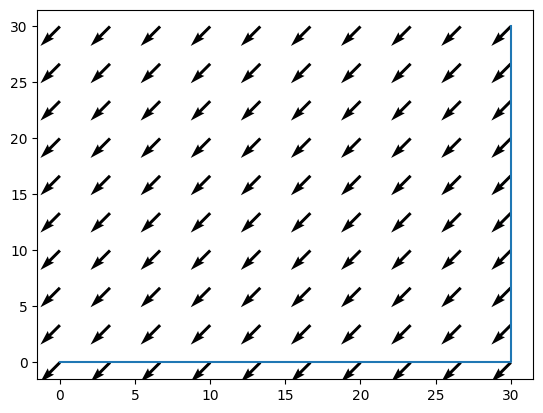

In [44]:
import matplotlib.pyplot as plt

plt.plot(sol.y[0], sol.y[1])

x = np.linspace(0, 30, 10)

X, Y = np.meshgrid(x, x)

U = - np.ones_like(X)
V = -np.ones_like(X)

plt.quiver(X, Y, U, V)

plt.show()

# Shooting Method

In [6]:
"""
Single-shooting solver for the minimum-time sailing BVP.

Replaces solve_bvp (collocation), which fails on this problem because the
optimal heading θ*(t) is bang-bang: it switches discretely between two tacking
angles at the no-go zone boundary. Collocation needs a smooth RHS; solve_ivp
(RK45) handles the switching by naturally taking smaller steps near it.

Unknowns: (λ₁, λ₂(0), T) — 3 values, 3 conditions:
    x(1) = xf[0],  y(1) = xf[1],  H(t=1) = 0
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root
import matplotlib.pyplot as plt

from variable_wind import (
    V_np, grad_V_xy, neg_H, optimal_theta, w, dw
)

x0 = np.array([0.0, 0.0])
xf = np.array([4.0, 4.0])


def ode(t, Y, T):
    x, y, l1, l2 = Y
    theta = optimal_theta(x, y, l1, l2)

    v_speed = V_np(theta, x, y)
    v_vec   = v_speed * np.array([np.cos(theta), np.sin(theta)])
    w_vec   = w(x, y)

    lam = np.array([l1, l2])
    dV  = grad_V_xy(theta, x, y)
    direction = np.array([np.cos(theta), np.sin(theta)])

    dl  = -T * (np.dot(lam, direction) * dV + dw(x, y).T @ lam)
    dxy = T * (v_vec + w_vec)

    return [dxy[0], dxy[1], dl[0], dl[1]]


def shoot(params):
    """Residual: integrate forward and return boundary-condition errors."""
    l1, l2_0, T = params
    if T <= 0:
        return [1e6, 1e6, 1e6]

    Y0 = [x0[0], x0[1], l1, l2_0]
    sol = solve_ivp(
        ode,
        [0.0, 1.0],
        Y0,
        args=(T,),
        method="RK45",
        max_step=5e-3,   # small enough to resolve tacking switches
        dense_output=True,
    )

    xf_got = sol.y[:, -1]
    x_end, y_end, l1_end, l2_end = xf_got

    theta_f = optimal_theta(x_end, y_end, l1_end, l2_end)
    H_f = -neg_H(theta_f, x_end, y_end, l1_end, l2_end)

    return [x_end - xf[0], y_end - xf[1], H_f]


# --- Initial guess ---
# λ̇₁ = 0 (constant), λ̇₂ = −T·λ₁ (linear decay).
# H(tf)=0 at y=xf[1] with V≈0 (no-go boundary) → λ₁·xf[1] ≈ 1.
T_guess   = 8.0
l1_guess  = 1.0 / (xf[1] + 1.5)   # ≈ 0.18 for xf=(4,4)
l2_guess  = 0.3

result = root(shoot, [l1_guess, l2_guess, T_guess], method="hybr", tol=1e-8)
print("root.success:", result.success)
print("residual:    ", result.fun)
print("(λ₁, λ₂₀, T):", result.x)

if not result.success:
    raise SystemExit("Shooting failed to converge — adjust initial guess.")

l1_sol, l2_sol, T_sol = result.x

# --- Reconstruct solution at fine resolution ---
Y0 = [x0[0], x0[1], l1_sol, l2_sol]
traj = solve_ivp(
    ode,
    [0.0, 1.0],
    Y0,
    args=(T_sol,),
    method="RK45",
    max_step=1e-3,
    dense_output=True,
)

t_plot = np.linspace(0, 1, 500)
Y_plot  = traj.sol(t_plot)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(Y_plot[0], Y_plot[1], "b-", lw=2, label="optimal path")
ax.plot(*x0, "go", ms=8, label="start")
ax.plot(*xf, "rs", ms=8, label="end")

margin = 0.5
xg = np.linspace(x0[0] - margin, xf[0] + margin, 10)
yg = np.linspace(x0[1] - margin, xf[1] + margin, 10)
Xg, Yg = np.meshgrid(xg, yg)
# wind direction for quiver: phi returns the wind vector, pointing that way
Uq = -np.ones_like(Xg)
Vq = -np.ones_like(Yg)
ax.quiver(Xg, Yg, Uq, Vq, alpha=0.4)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Optimal path  (T = {T_sol:.3f})")
ax.legend()
ax.set_aspect("equal")

ax = axes[1]
thetas = np.array([
    optimal_theta(Y_plot[0, i], Y_plot[1, i], Y_plot[2, i], Y_plot[3, i])
    for i in range(len(t_plot))
])
ax.plot(t_plot * T_sol, np.degrees(thetas))
ax.set_xlabel("time")
ax.set_ylabel("heading (deg)")
ax.set_title("Optimal heading θ*(t)")

plt.tight_layout()
plt.show()


KeyboardInterrupt: 